In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 2** - Mystery ML Model (2D)

A black-box model taking two inputs and returning a log-likelihood score. 
- Goal is to maximise on a noisy, multi-peaked surface.

- **Input** - 2D array
- **Optimisation Goal** - Maximise  
- **All-time best:** 0.6296 at [0.701, 0.958] (Week 10)

In [3]:
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_outputs.npy')

# New data for Week 12 (Function 2)
X_w12_new_point = np.array([0.72878, 0.948593], dtype=np.float64)
Y_w12_new_point = np.array([0.5269910229124568], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w12_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w12_new_point)
Y_updated = Y_all[unique_indices]

# Save the updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_outputs.npy', Y_updated)

print('Updated Inputs (X) - Function 2:', X_unique)
print('Updated Outputs (Y) - Function 2:', Y_updated)

Updated Inputs (X) - Function 2: [[0.14269907 0.34900513]
 [0.33864816 0.21386725]
 [0.34174959 0.02869772]
 [0.43816606 0.68501826]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.638512   0.01429   ]
 [0.656253   0.988919  ]
 [0.66579958 0.12396913]
 [0.677237   0.943693  ]
 [0.688961   0.010598  ]
 [0.69697    0.070707  ]
 [0.701022   0.958065  ]
 [0.70263656 0.9265642 ]
 [0.703106   0.923905  ]
 [0.72878    0.948593  ]
 [0.730653   0.213258  ]
 [0.736899   0.001     ]
 [0.84527543 0.71112027]
 [0.871256   0.999348  ]
 [0.87779099 0.7786275 ]
 [0.998312   0.002851  ]]
Updated Outputs (Y) - Function 2: [-0.06562362 -0.01385762  0.03874902  0.24461934  0.21496451  0.02310555
  0.29668333  0.51976639  0.53899612  0.51715684  0.55966119  0.49414992
  0.62962126  0.61120522  0.59071744  0.52699102  0.48809387  0.37180079
  0.29399291  0.05410069  0.42058624 -0.08088786]


## **Output Analysis**

- **w11 Output:** 0.517 at [0.677, 0.944]
- **w12 Output:** 0.527 at [0.729, 0.949] which is a marginal improvement

- **Comparison:** A small recovery from w11's 0.517 to 0.527, but still well below the w10 all-time best of 0.6296. 
    - The query [0.729, 0.949] has x1=0.729, which is further right than the known best (x1=0.701). 
    - The log-likelihood score is sensitive to x1 as queries with x1 above 0.710 consistently underperform. 
    - x2=0.949 is close to the best value of 0.958.

- **Real-World Implication:** In log-likelihood surfaces, narrow peaks with steep gradients are common when a model has a specific optimal parameterisation. 
    - The consistent underperformance when x1 drifts above 0.710 confirms x1≈0.701 is a critical constraint, not just a coincidence.

- **Model Clues:** w13 must tighten x1 back toward 0.701 while keeping x2 near 0.958. 
    - The std needs to be tighter than the 0.015 used recently, I will try std=0.010 with a much lower uniform component (5%) to keep the search locked on the W10 best coordinates.

## **Bayesian Optimisation** - Gaussian Processes

- The Matérn 2.5 + WhiteKernel GP is retained. 
    - The Matern 2.5 kernel is appropriate because the log-likelihood surface of a statistical model is typically smooth and twice-differentiable, there are no sharp discontinuities, just a landscape of peaks and ridges. 
    
- The WhiteKernel is critical here because this function explicitly involves noise: observed log-likelihood scores fluctuate between queries even in similar regions, as seen in the oscillations between 0.517 and 0.630 in recent weeks. 

    - Without the WhiteKernel, the GP would attempt to fit every noisy reading exactly, producing an overfit surrogate with misleading gradients. 
    
- The Yeo-Johnson transformation stabilises the output distribution across the full range from negative early values to the current best of 0.6296. 
    - The consistent underperformance when x1 drifts above 0.710 — observed across W11 (x1=0.677, score 0.517) and W12 (x1=0.729, score 0.527), tells the GP that x1≈0.701 sits at a sensitivity boundary, and the model's ARD-style length scale fitting will reinforce a shorter effective length scale in that dimension.

In [4]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20)

model.fit(X_unique, Y_transformed)

Original Y: [-0.06562362 -0.01385762  0.03874902  0.24461934  0.21496451  0.02310555
  0.29668333  0.51976639  0.53899612  0.51715684  0.55966119  0.49414992
  0.62962126  0.61120522  0.59071744  0.52699102  0.48809387  0.37180079
  0.29399291  0.05410069  0.42058624 -0.08088786]
Transformed Y: [-1.52664819 -1.38627889 -1.23200047 -0.50552185 -0.62266532 -1.2791619
 -0.28928791  0.79613594  0.90222094  0.78189703  1.01851037  0.65797848
  1.43000127  1.31899501  1.19776486  0.83575262  0.62584107  0.04694651
 -0.30079552 -1.18464859  0.28102516 -1.56606062]


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**

- EI with ξ=0.01 is retained, but the focused grid is tightened to std=0.010 with a 95/5 focused-to-uniform split. 
    - The tightening is the most important change this week. 
    
- The last three queries have all drifted in x1 — 0.677, 0.701, 0.729 — producing scores of 0.517, 0.630, and 0.527 respectively. 
    - The pattern is clear: x1=0.701 is the optimal value and the search keeps sliding away from it. 
    - With std=0.010, 95% of focused samples will have x1 in the range [0.681, 0.721], preventing the drift that has cost multiple weeks of progress. 
    
- EI with ξ=0.01 was chosen over UCB because we have a well-established best of 0.6296 and the goal is exploitation with intentions of finding a configuration that genuinely beats it rather than exploring uncertain regions. 

    - A low ξ value tells EI to find even marginal improvements over the current best, keeping the acquisition surface sharply peaked around the W10 best coordinates rather than spreading across the high-x2 region broadly.

In [5]:
def expected_improvement(X, model, y_max, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1); mu = mu.reshape(-1, 1)

    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

w_best = np.array([0.701022, 0.958065])

x_focused = np.random.normal(loc=w_best, scale=0.01, size=(9500, 2))
x_uniform = np.random.uniform(0, 1, size=(500, 2))
x_grid = np.vstack([x_focused, x_uniform])
x_grid = np.clip(x_grid, 0, 1)

y_max = np.max(Y_transformed)
ei_values = expected_improvement(x_grid, model, y_max, xi=0.01)
next_query = x_grid[np.argmax(ei_values)]

print(f'Best coordinates: {w_best}')
print(f'Week 13 Query Recommendation (Function 2): {next_query[0]:.6f}-{next_query[1]:.6f}')

Best coordinates: [0.701022 0.958065]
Week 13 Query Recommendation (Function 2): 0.706778-0.927750


## **Visualisation**

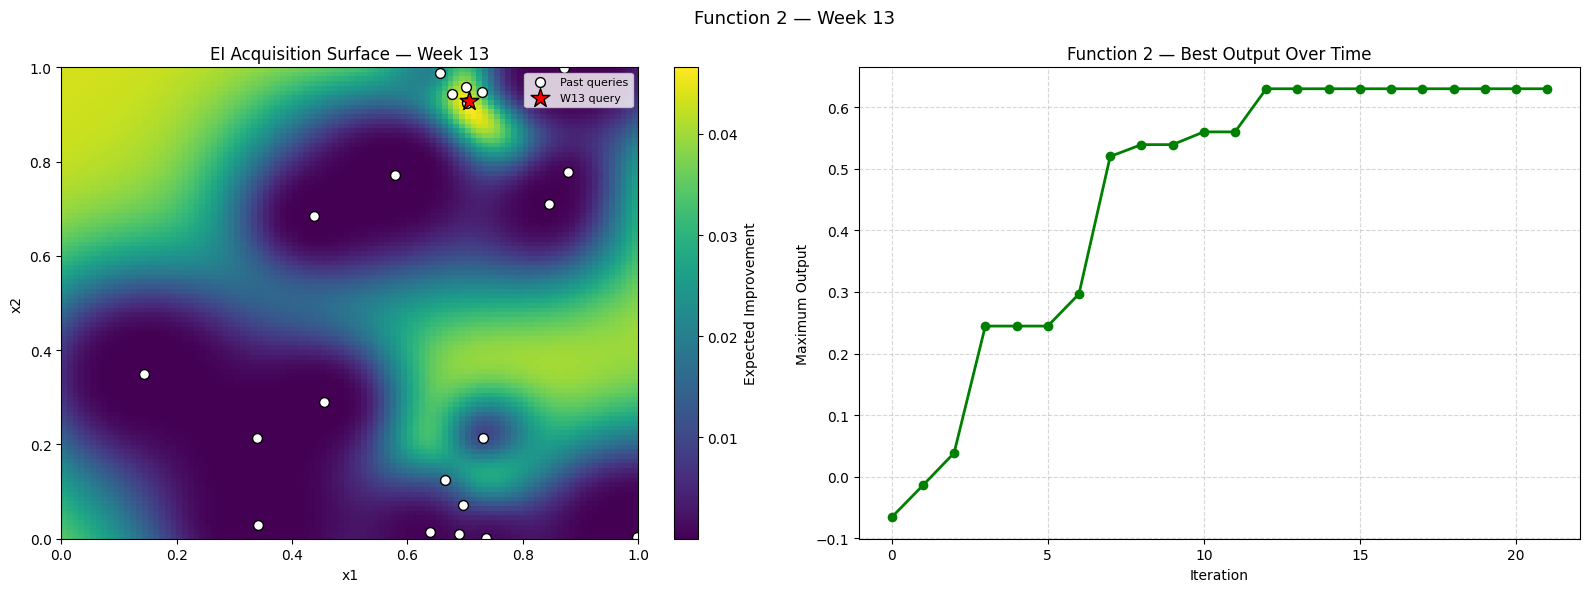

In [6]:
res = 100
X1, X2 = np.meshgrid(np.linspace(0, 1, res), np.linspace(0, 1, res))
X_plot = np.vstack([X1.ravel(), X2.ravel()]).T

y_max_vis = np.max(Y_transformed)

def expected_improvement_vis(X, model, y_max, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1); mu = mu.reshape(-1, 1)
    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

ei_plot = expected_improvement_vis(X_plot, model, y_max_vis).reshape(res, res)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sc = ax1.imshow(ei_plot, extent=[0,1,0,1], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(sc, ax=ax1, label='Expected Improvement')
ax1.scatter(X_unique[:,0], X_unique[:,1], c='white', edgecolors='black', s=50, label='Past queries')
ax1.scatter(next_query[0], next_query[1], c='red', marker='*', s=200, edgecolors='black', zorder=7, label='W13 query')
ax1.set_title('EI Acquisition Surface — Week 13')
ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.legend(fontsize=8)

running_max = np.maximum.accumulate(Y_updated)
ax2.plot(running_max, marker='o', color='green', linewidth=2)
ax2.set_title('Function 2 — Best Output Over Time')
ax2.set_xlabel('Iteration'); ax2.set_ylabel('Maximum Output')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 2 — Week 13', fontsize=13)
plt.tight_layout()
plt.show()